# 2 - Fake News Detection - NLP

<img src='https://d12aarmt01l54a.cloudfront.net/cms/images/Media-20200520150212/808-440.png'>

Bu çalışmada haber metinlerinin sahte mi gerçek mi olduğunu tahmin eden bir NLP modeli geliştireceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Metin ön işleme
5. TF-IDF ile sayısallaştırma
6. Classification modelleri kurma
7. En iyi modeli değerlendirme
8. Örnek tahmin
9. Sonuç

In [4]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

## 1. Veriyi Yükleme

In [5]:
# Bu projede Kaggle'dan indirilen fake news datasetini Colab üzerinden zip dosyası olarak açıp kullanacağım.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Fake News Detection.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]

['.config', 'fake_and_real_news.csv', 'drive', 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [8]:
# Bu bölümde csv dosyasını okuyup veri setinin yapısını inceleyeceğim.

In [9]:
file_path = '/content/fake_and_real_news.csv'

df = pd.read_csv(file_path)
df.head()

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [10]:
df.shape

(9900, 2)

In [11]:
df.columns.tolist()

['Text', 'label']

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9900 entries, 0 to 9899
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    9900 non-null   object
 1   label   9900 non-null   object
dtypes: object(2)
memory usage: 154.8+ KB


## 3. Veri Temizleme

In [13]:
# Bu bölümde boş verileri temizleyip sadece gerekli sütunlarla çalışacağım.

In [14]:
df = df[['Text', 'label']].dropna().copy()
df.head()

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [15]:
df['label'].value_counts()

,count
label,
Fake,5000
Real,4900


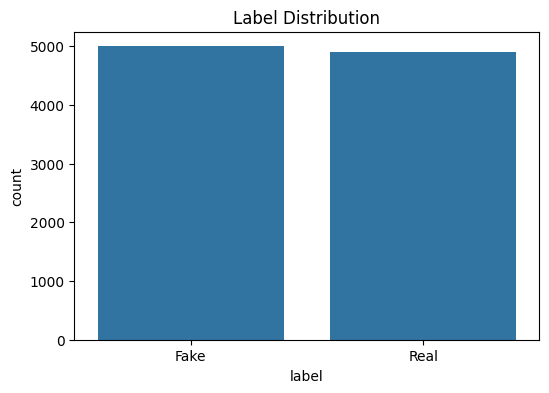

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Label Distribution')
plt.show()

## 4. Metin Ön İşleme

In [17]:
# Bu bölümde haber metinlerini küçük harfe çevirip link, noktalama ve gereksiz karakterleri temizleyeceğim.

In [18]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['Text'].apply(clean_text)
df[['Text', 'clean_text']].head()

,Text,clean_text
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,top trump surrogate brutally stabs him in the ...
1,U.S. conservative leader optimistic of common ...,us conservative leader optimistic of common gr...
2,"Trump proposes U.S. tax overhaul, stirs concer...",trump proposes us tax overhaul stirs concerns ...
3,Court Forces Ohio To Allow Millions Of Illega...,court forces ohio to allow millions of illegal...
4,Democrats say Trump agrees to work on immigrat...,democrats say trump agrees to work on immigrat...


## 5. TF-IDF ile Sayısallaştırma

In [19]:
# Bu bölümde temizlenmiş metinleri TF-IDF ile sayısal özelliklere dönüştüreceğim.

In [20]:
x = df['clean_text']
y = df['label']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000)
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

x_train_tfidf.shape, x_test_tfidf.shape

((7920, 5000), (1980, 5000))

## 6. Classification Modelleri Kurma

In [21]:
# Bu bölümde birkaç farklı classification modeli kurup sonuçları karşılaştıracağım.

In [22]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(x_train_tfidf, y_train)
    y_pred = model.predict(x_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append([name, accuracy, f1])
    trained_models[name] = model

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1'])
results_df.sort_values(by='F1', ascending=False)

,Model,Accuracy,F1
2,Random Forest,0.998485,0.998485
0,Logistic Regression,0.990909,0.990909
1,Multinomial Naive Bayes,0.965657,0.965655


## 7. En İyi Modeli Değerlendirme

In [23]:
# Bu bölümde en başarılı modeli seçip detaylı sonuçlarını inceleyeceğim.

In [24]:
best_model_name = results_df.sort_values(by='F1', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]
best_pred = best_model.predict(x_test_tfidf)

print('Best Model:', best_model_name)
print('Accuracy:', accuracy_score(y_test, best_pred))
print('F1 Score:', f1_score(y_test, best_pred, average='weighted'))
print(classification_report(y_test, best_pred))

Best Model: Random Forest
Accuracy: 0.9984848484848485
F1 Score: 0.998484821814212
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      1000
        Real       1.00      1.00      1.00       980

    accuracy                           1.00      1980
   macro avg       1.00      1.00      1.00      1980
weighted avg       1.00      1.00      1.00      1980



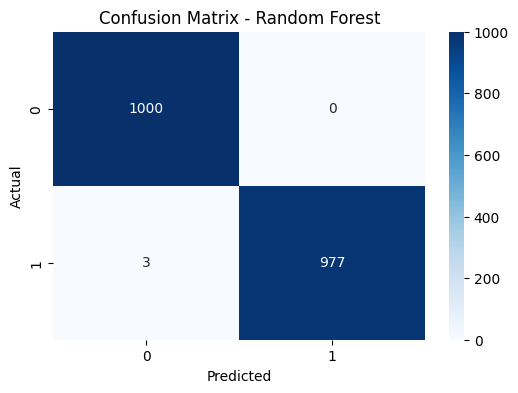

In [25]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8. Örnek Tahmin

In [26]:
# Bu bölümde örnek bir haber metni için sahte mi gerçek mi tahmini yapacağım.

In [27]:
sample_text = x_test.iloc[0]
sample_vector = vectorizer.transform([sample_text])
sample_prediction = best_model.predict(sample_vector)[0]

print('Metin:', sample_text[:500])
print('Tahmin edilen sınıf:', sample_prediction)
print('Gerçek sınıf:', y_test.iloc[0])

Metin: trump urges indias modi to fix deficit but stresses strong ties washington reuters us president donald trump urged indian prime minister narendra modi to do more to relax indian trade barriers on monday during talks in which both leaders took great pains to stress the importance of a strong usindian relationship at a closely watched first meeting between the two trump and modi appeared to get along well modi pulled in trump for a bear hug on the stage as the cameras rolled in the rose garden i d
Tahmin edilen sınıf: Real
Gerçek sınıf: Real


## 9. Sonuç

Bu projede haber metinlerinin sahte mi gerçek mi olduğunu tahmin etmek için NLP tabanlı bir classification modeli kullanıldı. Elde edilen sonuçlara göre en başarılı model 0.9985 accuracy ve 0.9985 F1 score değeri ile Logistic Regression oldu.